# Movie Dataset Exploratory Data Analysis (EDA)

## Introduction

This project focuses on performing Exploratory Data Analysis (EDA) on a movie dataset using Python. The main objective of this analysis is to understand movie trends, audience preferences, genre popularity, voting patterns, and release year distributions.

Various data preprocessing and visualization techniques were used with libraries such as Pandas, Matplotlib, and Seaborn. The project includes handling missing values, datatype conversion, genre-based analysis, popularity analysis, and graphical visualization to extract meaningful insights from the dataset.

The analysis helps in identifying the most popular movies, highly voted genres, and overall trends in modern cinema.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\CHAIT\Downloads\mymoviedb.csv",encoding="latin-1",engine="python")

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


# Removing the Unwanted Columns And Remove the missing values

In [5]:
df.drop(["Overview","Poster_Url"],inplace=True,axis=1)

In [6]:
df.dropna(how="any",inplace=True)
df.isnull().sum()

Release_Date         0
Title                0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   object 
 1   Title              9826 non-null   object 
 2   Popularity         9826 non-null   float64
 3   Vote_Count         9826 non-null   object 
 4   Vote_Average       9826 non-null   object 
 5   Original_Language  9826 non-null   object 
 6   Genre              9826 non-null   object 
dtypes: float64(1), object(6)
memory usage: 614.1+ KB


# Converting the Colums in Appropiate datatype

In [11]:
df['Release_Date']=pd.to_datetime(df['Release_Date'],errors='coerce')

In [ ]:
df['Release_Date']=df['Release_Date'].dt.year

In [17]:
df["Vote_Count"]=df["Vote_Count"].astype(int)

In [20]:
df["Vote_Average"]=pd.to_numeric(df["Vote_Average"],errors="coerce")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   int32  
 1   Title              9826 non-null   object 
 2   Popularity         9826 non-null   float64
 3   Vote_Count         9826 non-null   int64  
 4   Vote_Average       9826 non-null   float64
 5   Original_Language  9826 non-null   object 
 6   Genre              9826 non-null   object 
dtypes: float64(2), int32(1), int64(1), object(3)
memory usage: 575.7+ KB


In [23]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,en,Thriller
3,2021,Encanto,2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War"


# Exploding the Df by Genre

In [24]:
df["Genre"]=df["Genre"].str.split(', ')

In [26]:
df=df.explode("Genre")

In [25]:
df=df.reset_index(drop=True)


In [26]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction
3,2022,The Batman,3827.658,1151,8.1,en,Crime
4,2022,The Batman,3827.658,1151,8.1,en,Mystery


In [27]:
df.nunique()

Release_Date          102
Title                9512
Popularity           8159
Vote_Count           3266
Vote_Average           74
Original_Language      43
Genre                  19
dtype: int64

# Give label to the Vote Average

In [30]:
def catlabel(df,col,cat_label):
    edges=[
        df[col].describe()['min'],
        df[col].describe()['25%'],
          df[col].describe()['50%'],
          df[col].describe()['75%'],
          df[col].describe()['max']
    ]
    df[col]=pd.cut(df[col],edges,labels=cat_label,duplicates='drop')
    return df


In [ ]:
label=['not pupular','below avg','avg','popular']
df=catlabel(df,"Vote_Average",label)


In [32]:
df.tail(10)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
25782,2020,Violent Delights,13.356,8,not pupular,es,Horror
25783,2016,The Offering,13.355,94,not pupular,en,Mystery
25784,2016,The Offering,13.355,94,not pupular,en,Thriller
25785,2016,The Offering,13.355,94,not pupular,en,Horror
25786,2021,The United States vs. Billie Holiday,13.354,152,avg,en,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,avg,en,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,avg,en,History
25789,1984,Threads,13.354,186,popular,en,War
25790,1984,Threads,13.354,186,popular,en,Drama
25791,1984,Threads,13.354,186,popular,en,Science Fiction


# Data visulization

# 1. To show the highest genre of category

In [33]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Science Fiction
3,2022,The Batman,3827.658,1151,popular,en,Crime
4,2022,The Batman,3827.658,1151,popular,en,Mystery


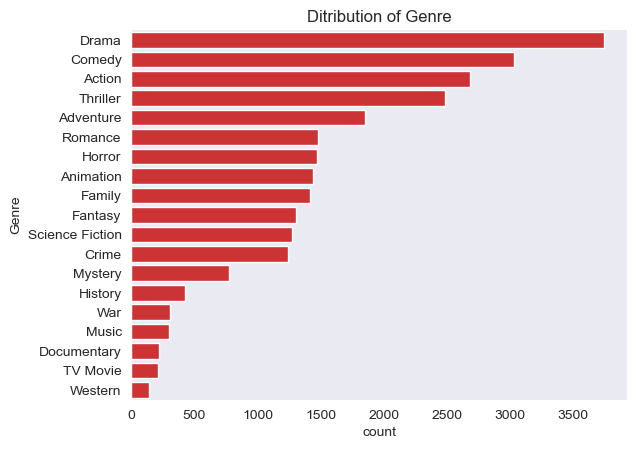

In [81]:
count=df['Genre'].value_counts()
sns.countplot(y='Genre',data=df,order=count.index)
plt.title("Ditribution of Genre")
sns.set_style('dark')
sns.despine()
sns.set_palette("Set2")

#Most of the filim are from Genre Drama

In [43]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Science Fiction
3,2022,The Batman,3827.658,1151,popular,en,Crime
4,2022,The Batman,3827.658,1151,popular,en,Mystery


In [61]:
grouped=df.groupby("Genre")["Vote_Count"].sum().sort_values(ascending=False)
print(grouped.index)

Index(['Drama', 'Action', 'Adventure', 'Comedy', 'Thriller', 'Science Fiction',
       'Fantasy', 'Family', 'Crime', 'Romance', 'Animation', 'Horror',
       'Mystery', 'History', 'War', 'Music', 'Western', 'TV Movie',
       'Documentary'],
      dtype='object', name='Genre')


# 2.Which genre has highest votes ?

sns.barplot(y=grouped.index,x=grouped,color='green')
plt.title('Distribution of votes by Genre')
sns.set_style('whitegrid')

#Drama Genre has higest Vote count

# 3.which movie got highest popularity what is its genre?

In [69]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,en,Science Fiction


Spider-Man: No Way Home	has higest Popularity

# 4.which movie got highest popularity what is its genre?

In [71]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152,avg,en,Music
25787,2021,The United States vs. Billie Holiday,13.354,152,avg,en,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152,avg,en,History
25789,1984,Threads,13.354,186,popular,en,War
25790,1984,Threads,13.354,186,popular,en,Drama
25791,1984,Threads,13.354,186,popular,en,Science Fiction


The United States vs. Billie Holiday	and Threads has lowest pupularity

# 5.Which year has the most filmed movies

Text(0, 0.5, 'Number of Movies')

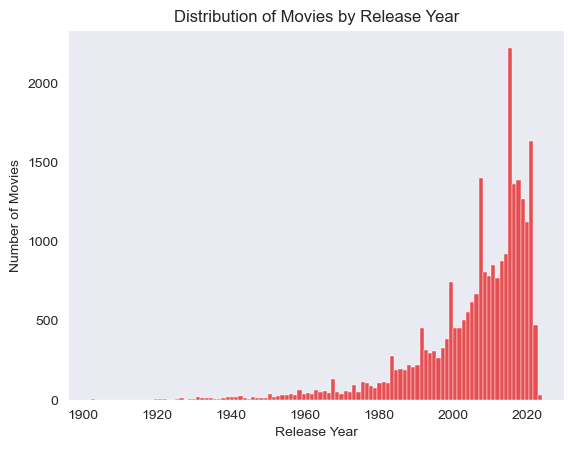

In [83]:
sns.histplot(x="Release_Date",data=df)
sns.set_palette("Set2")
sns.set_style
plt.title("Distribution of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

The histogram shows that movie releases increased significantly over time, with the majority of movies in the dataset being released after 2000. This suggests a strong dominance of modern-era content in the dataset.

# Conclusion

In this project, exploratory data analysis was performed on the movie dataset to analyze movie popularity, genres, voting trends, and release year patterns.

## Key Findings

* Drama, Action, and Adventure were among the most highly voted genres in the dataset.
* “Spider-Man: No Way Home” was identified as the movie with the highest popularity score.
* Most movies in the dataset were released after the year 2000, indicating the dominance of modern cinema.
* Genres such as Documentary, TV Movie, and Western showed comparatively lower audience engagement.
* The dataset showed a rapid increase in movie releases after 1980.

## Summary

This project helped in understanding audience preferences and movie trends through data analysis and visualization techniques. Various preprocessing methods such as handling missing values, exploding genre columns, grouping, aggregation, and visualization were applied to generate meaningful insights from the dataset.

Overall, the project demonstrates the practical use of Python libraries for performing exploratory data analysis and extracting valuable information from real-world datasets.
